<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/neural_network_basics/experiment_dnn_fashion_mnist_multiclass_classification_with_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

Data Collection

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Understand Dataset

In [ ]:
print(X_train.shape)

print(y_train.shape)

(60000, 28, 28)
(60000,)


Visualize Data

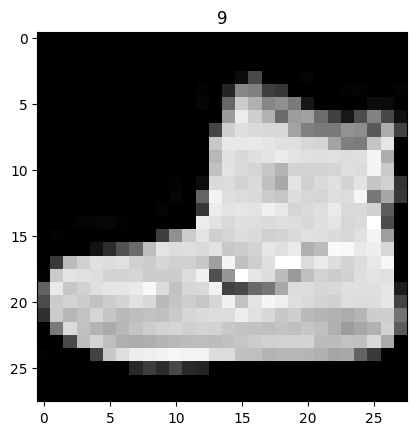

In [ ]:
plt.imshow(X_train[0], cmap="gray")

plt.title(y_train[0])

plt.show()

Data Preprocessing

Normalize Pixels

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0

Flatten Images

In [ ]:
X_train = X_train.reshape(
    -1,
    784
)

X_test = X_test.reshape(
    -1,
    784
)

Train Validation Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.2,

    random_state=42
)

Build Deep Learning Model

Beginner DNN

In [ ]:
model = Sequential()

model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(784,)
    )
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Production-Level DNN

In [ ]:
model = Sequential()

# ====================================================
# BLOCK 1
# ====================================================

model.add(
    Dense(
        512,
        activation="relu",
        input_shape=(784,)
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# BLOCK 2
# ====================================================

model.add(
    Dense(
        256,
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# BLOCK 3
# ====================================================

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.2))

# ====================================================
# OUTPUT
# ====================================================

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

Compile Model

In [ ]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

Configure Training Callbacks

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True
)

Learning Rate Scheduling

In [ ]:
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5
)

Train Model

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    batch_size=128,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7936 - loss: 0.5788 - val_accuracy: 0.8358 - val_loss: 0.4501 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8400 - loss: 0.4412 - val_accuracy: 0.8559 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8529 - loss: 0.4040 - val_accuracy: 0.8467 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8569 - loss: 0.3878 - val_accuracy: 0.8718 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8634 - loss: 0.3732 - val_accuracy: 0.8666 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8668 - loss: 0.3641 - val_accuracy: 0.8677 - val_loss: 0.3621 - learning_rate: 0.0010
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8720 

Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8928 - loss: 0.3187
Test Accuracy: 0.892799973487854


Predictions

In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[9 2 1 1 6 1 4 6 5 7]


Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        predicted_classes
    )
)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.82      0.81      1000
           3       0.90      0.89      0.89      1000
           4       0.81      0.81      0.81      1000
           5       0.97      0.97      0.97      1000
           6       0.73      0.71      0.72      1000
           7       0.94      0.97      0.96      1000
           8       0.98      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    predicted_classes
)

print(cm)

[[868   0  15  20   2   1  85   1   8   0]
 [  2 970   4  19   3   0   1   0   1   0]
 [ 15   1 824   8  79   0  73   0   0   0]
 [ 19   9  11 886  42   0  30   0   3   0]
 [  0   0  93  28 809   0  68   0   2   0]
 [  0   0   0   1   0 969   0  17   0  13]
 [128   0  81  20  57   0 706   0   8   0]
 [  0   0   0   0   0  12   0 972   0  16]
 [  3   0   4   4   6   3   5   3 972   0]
 [  0   0   0   0   0  10   1  37   0 952]]


Visualize Training Curves

Accuracy Curves

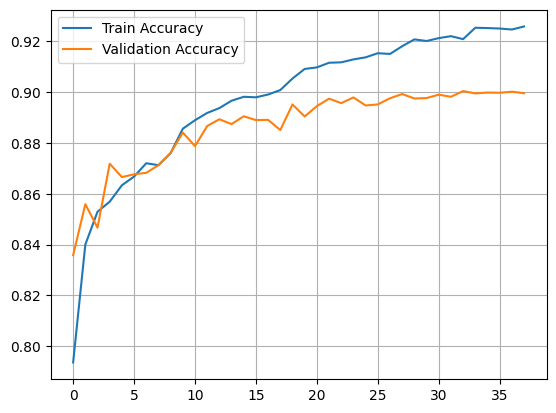

In [ ]:
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

Loss Curves

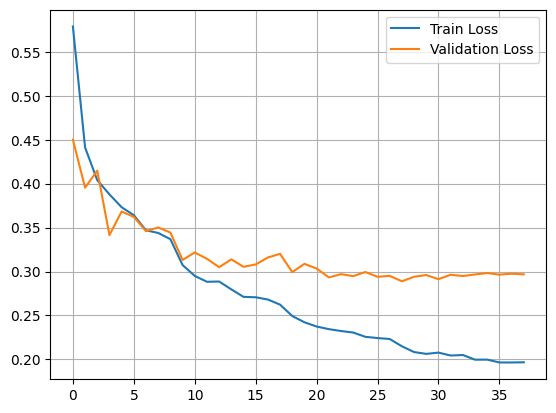

In [ ]:
plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

Predict New Sample

In [ ]:
sample = X_test[0].reshape(1, 784)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
9


Save Model

In [ ]:
model.save(
    "deep_learning_model.keras"
)

Load Model

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "deep_learning_model.keras"
)